In [1]:
print("hi")

hi


In [2]:
# Full PySpark preprocessing + augmentation script for Kaggle
# Input file: /mnt/data/MQTTEEB-D_updated_cleaned.csv
# Output: /kaggle/working/MQTT_FINAL_DATA_augmented.csv

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType
import math

# --- Config ---
input_path = "/kaggle/input/mmds-mqtt/MQTTEEB-D_cleaned_data.csv"
output_path = "/kaggle/working/MQTT_FINAL_DATA_augmented.csv"  # single CSV will be written (coalesced)
multiplier = 5            # how many times bigger you want the dataset (e.g., 5 => 200k -> ~1M)
noise_factor = 0.01       # relative noise magnitude: 0.005 - 0.02 recommended
label_candidates = ["label", "target", "class"]  # if your label column has a different name, set it here

# --- Start Spark ---
spark = SparkSession.builder \
    .appName("MQTT_preprocess_augment") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# --- Load ---
df = spark.read.option("header", True).option("inferSchema", True).csv(input_path)
print("Initial count:", df.count())
df.printSchema()

# --- 1) Remove NULL rows (user requested) ---
df = df.dropna()
print("After dropna count:", df.count())

# --- 2) Identify numeric columns robustly ---
numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]
# if inferSchema mis-classified numeric features, you can explicitly set numeric_cols = [...]
print("Numeric columns detected:", numeric_cols)

# --- 3) Replace outliers (IQR) with column MEAN (user requested MEAN) ---
for c in numeric_cols:
    try:
        q1, q3 = df.approxQuantile(c, [0.25, 0.75], 0.01)
    except Exception:
        continue
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mean_val = df.select(F.mean(F.col(c)).alias("m")).collect()[0]["m"]
    if mean_val is None: 
        continue
    df = df.withColumn(c, F.when((F.col(c) < lower) | (F.col(c) > upper), F.lit(mean_val)).otherwise(F.col(c)))

cleaned_count = df.count()
print("After outlier replacement count:", cleaned_count)

# --- 4) Augmentation: stratified if label exists, else global ---
# Find label column if present
label_col = None
for cand in label_candidates:
    if cand in df.columns:
        label_col = cand
        break

if multiplier <= 1:
    print("Multiplier <= 1; nothing to augment. Saving cleaned dataset.")
    df.coalesce(1).write.mode("overwrite").option("header", True).csv(output_path)
else:
    if label_col:
        print(f"Label column detected: '{label_col}'. Performing stratified augmentation with multiplier={multiplier}.")
        # compute per-class augment
        classes = [row[label_col] for row in df.select(label_col).distinct().collect()]
        augmented_parts = []
        for cls in classes:
            cls_df = df.filter(F.col(label_col) == cls)
            cls_count = cls_df.count()
            desired = int(cls_count * multiplier)
            if desired == cls_count:
                # no augmentation needed for this class
                augmented_parts.append(cls_df)
                continue

            # compute number of full copies and extra
            times = desired // cls_count
            extra = desired % cls_count

            # start with original class rows
            part = cls_df
            # add (times-1) copies by unioning sample(withReplacement=True, fraction=1.0)
            # doing sample(withReplacement=True, fraction=1.0) yields approx same size with replacement
            if times > 1:
                for _ in range(times - 1):
                    part = part.unionByName(cls_df.sample(withReplacement=True, fraction=1.0))
            # add extra rows via fractional sampling (safe fraction <=1)
            if extra > 0:
                frac = extra / float(cls_count)
                extra_part = cls_df.sample(withReplacement=True, fraction=float(frac))
                part = part.unionByName(extra_part)

            # add small gaussian noise to numeric columns to diversify synthetic rows
            # compute stddev per numeric col (for the whole dataset to be stable)
            stats = cls_df.select(*[F.stddev(F.col(c)).alias(c) for c in numeric_cols]).collect()[0].asDict()
            for c in numeric_cols:
                stddev_c = stats.get(c) or 0.0
                if stddev_c and stddev_c > 0:
                    part = part.withColumn(c, F.col(c) + F.randn() * (F.lit(stddev_c) * F.lit(noise_factor)))
            augmented_parts.append(part)

        augmented = augmented_parts[0]
        for part in augmented_parts[1:]:
            augmented = augmented.unionByName(part)

    else:
        # No label; global augmentation
        print(f"No label column found. Performing global augmentation with multiplier={multiplier}.")
        base_count = df.count()
        desired_total = int(base_count * multiplier)

        times = desired_total // base_count
        extra = desired_total % base_count

        # start with original
        augmented = df
        if times > 1:
            for _ in range(times - 1):
                augmented = augmented.unionByName(df.sample(withReplacement=True, fraction=1.0))
        if extra > 0:
            frac = extra / float(base_count)
            extra_part = df.sample(withReplacement=True, fraction=float(frac))
            augmented = augmented.unionByName(extra_part)

        # add small gaussian noise to numeric columns
        stats = df.select(*[F.stddev(F.col(c)).alias(c) for c in numeric_cols]).collect()[0].asDict()
        for c in numeric_cols:
            stddev_c = stats.get(c) or 0.0
            if stddev_c and stddev_c > 0:
                augmented = augmented.withColumn(c, F.col(c) + F.randn() * (F.lit(stddev_c) * F.lit(noise_factor)))

    print("Augmented count (approx):", augmented.count())

    # Optional: shuffle rows to mix original & synthetic
    augmented = augmented.orderBy(F.rand())

    # Save final augmented dataset
    augmented.coalesce(1).write.mode("overwrite").option("header", True).csv(output_path)
    print("Saved augmented dataset to:", output_path)

# --- Stop Spark ---
spark.stop()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/24 05:15:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Initial count: 222813
root
 |-- timestamp: double (nullable = true)
 |-- tcp_flags: string (nullable = true)
 |-- tcp_time_delta: double (nullable = true)
 |-- tcp_len: integer (nullable = true)
 |-- mqtt_conack_flags: string (nullable = true)
 |-- mqtt_conflag_cleansess: integer (nullable = true)
 |-- mqtt_conflags: string (nullable = true)
 |-- mqtt_dupflag: integer (nullable = true)
 |-- mqtt_hdrflags: string (nullable = true)
 |-- mqtt_kalive: integer (nullable = true)
 |-- mqtt_msg: integer (nullable = true)
 |-- mqtt_qos: integer (nullable = true)
 |-- label: string (nullable = true)



After dropna count: 222567
Numeric columns detected: ['timestamp', 'tcp_time_delta', 'tcp_len', 'mqtt_conflag_cleansess', 'mqtt_dupflag', 'mqtt_kalive', 'mqtt_msg', 'mqtt_qos']


After outlier replacement count: 222567
Label column detected: 'label'. Performing stratified augmentation with multiplier=5.


Augmented count (approx): 1113536


Saved augmented dataset to: /kaggle/working/MQTT_FINAL_DATA_augmented.csv


In [3]:
# 1. Start Spark and load CSV
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("MQTT_EDA") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

path = "/kaggle/working/MQTT_FINAL_DATA_augmented.csv"
# If the file was saved as a CSV directory (Spark output), give the folder path; Spark can read it.
df = spark.read.option("header", True).option("inferSchema", True).csv(path)


In [4]:
# 2. Shape and schema
rows = df.count()
cols = len(df.columns)
print(f"Rows: {rows}, Columns: {cols}")
print("Column list:")
print(df.columns)
print("\nSchema:")
df.printSchema()


Rows: 1113536, Columns: 13
Column list:
['timestamp', 'tcp_flags', 'tcp_time_delta', 'tcp_len', 'mqtt_conack_flags', 'mqtt_conflag_cleansess', 'mqtt_conflags', 'mqtt_dupflag', 'mqtt_hdrflags', 'mqtt_kalive', 'mqtt_msg', 'mqtt_qos', 'label']

Schema:
root
 |-- timestamp: double (nullable = true)
 |-- tcp_flags: string (nullable = true)
 |-- tcp_time_delta: double (nullable = true)
 |-- tcp_len: double (nullable = true)
 |-- mqtt_conack_flags: string (nullable = true)
 |-- mqtt_conflag_cleansess: double (nullable = true)
 |-- mqtt_conflags: string (nullable = true)
 |-- mqtt_dupflag: double (nullable = true)
 |-- mqtt_hdrflags: string (nullable = true)
 |-- mqtt_kalive: double (nullable = true)
 |-- mqtt_msg: double (nullable = true)
 |-- mqtt_qos: double (nullable = true)
 |-- label: string (nullable = true)



In [5]:
# 3. Summary stats and null counts
# Summary statistics
summary = df.describe()
display(summary.toPandas())   # in Kaggle this will render as a table

# Null counts per column
null_counts = df.select([F.count(F.when(F.col(c).isNull() | F.col(c).isin(["", "NA", "null"]), c)).alias(c)
                         for c in df.columns])
display(null_counts.toPandas())


25/11/24 05:18:33 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,summary,timestamp,tcp_flags,tcp_time_delta,tcp_len,mqtt_conack_flags,mqtt_conflag_cleansess,mqtt_conflags,mqtt_dupflag,mqtt_hdrflags,mqtt_kalive,mqtt_msg,mqtt_qos,label
0,count,1113536,1113536,1113536,1113536,1113536,1113536,1113536,1113536,1113536,1113536,1113536,1113536,1113536
1,mean,1.725878477113431E9,None,1.725878436350501E9,289.2866860147322,0.0,0.5389335457914276,0.0,5.276229891286504E-7,None,32.33654725425562,184.36933210741336,0.6403109011960283,None
2,stddev,18697.033326621677,None,18647.93355063805,407.57579002061135,0.0,0.4985115916401836,0.0,1.9527868843665557E-5,None,29.910577071676975,476.1260507275021,0.9331404008771915,None
3,min,1.7258512032166698E9,0x0010,1.7258512820703118E9,-11.67518778960913,0,-0.02245343613138596,0,-4.000428598595978E-6,0x00,-1.3228938171443716,-25.96719717728685,-0.04266191483645473,bruteforce
4,max,1.725923737132092E9,0x0019,1.7259234854279902E9,1482.0478717129354,0x79,1.024507461687953,0xf2,7.261626363925161E-4,0xe0,61.34612384650273,1442.8360251037213,3.0214647163631625,slowite


,timestamp,tcp_flags,tcp_time_delta,tcp_len,mqtt_conack_flags,mqtt_conflag_cleansess,mqtt_conflags,mqtt_dupflag,mqtt_hdrflags,mqtt_kalive,mqtt_msg,mqtt_qos,label
0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# 4. Class balance: detect likely label column and show counts
# Replace 'label' with your actual label name if different.
possible_labels = ["label", "target", "class"]
label_col = next((c for c in possible_labels if c in df.columns), None)
if label_col:
    print("Detected label column:", label_col)
    df.groupBy(label_col).count().orderBy("count", ascending=False).show(truncate=False)
else:
    print("No standard label column found. Columns available:", df.columns)


Detected label column: label


+----------+------+
|label     |count |
+----------+------+
|malformed |528195|
|dos       |209076|
|bruteforce|136830|
|slowite   |100559|
|legitimate|88073 |
|flood     |50803 |
+----------+------+



In [7]:
# 5. Numeric columns detection
from pyspark.sql.types import NumericType
numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]
print("Numeric columns:", numeric_cols)


Numeric columns: ['timestamp', 'tcp_time_delta', 'tcp_len', 'mqtt_conflag_cleansess', 'mqtt_dupflag', 'mqtt_kalive', 'mqtt_msg', 'mqtt_qos']


In [8]:
# 6. Correlation matrix (Pearson) for numeric features
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import numpy as np

if len(numeric_cols) >= 2:
    assembler = VectorAssembler(inputCols=numeric_cols, outputCol="num_features_vec")
    vec_df = assembler.transform(df.select(*numeric_cols)).select("num_features_vec")
    corr_mat = Correlation.corr(vec_df, "num_features_vec", "pearson").head()[0]
    corr_arr = corr_mat.toArray().tolist()
    corr_df = pd.DataFrame(corr_arr, index=numeric_cols, columns=numeric_cols)
    display(corr_df)   # shows correlation table
else:
    print("Not enough numeric columns to compute correlation.")


,timestamp,tcp_time_delta,tcp_len,mqtt_conflag_cleansess,mqtt_dupflag,mqtt_kalive,mqtt_msg,mqtt_qos
timestamp,1.000000,0.997342,0.000789,0.004829,-0.007899,0.004801,0.004098,0.004394
tcp_time_delta,0.997342,1.000000,0.001760,0.005149,-0.007865,0.005121,0.004591,0.005647
tcp_len,0.000789,0.001760,1.000000,-0.658385,0.055553,-0.658384,0.494056,0.783096
mqtt_conflag_cleansess,0.004829,0.005149,-0.658385,1.000000,-0.029220,0.999903,-0.418646,-0.741849
mqtt_dupflag,-0.007899,-0.007865,0.055553,-0.029220,1.000000,-0.029232,-0.010334,0.038001
mqtt_kalive,0.004801,0.005121,-0.658384,0.999903,-0.029232,1.000000,-0.418636,-0.741848
mqtt_msg,0.004098,0.004591,0.494056,-0.418646,-0.010334,-0.418636,1.000000,0.554121
mqtt_qos,0.004394,0.005647,0.783096,-0.741849,0.038001,-0.741848,0.554121,1.000000


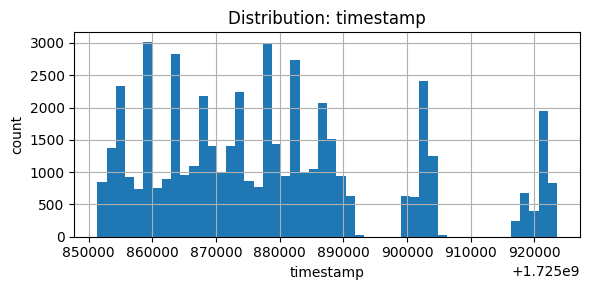

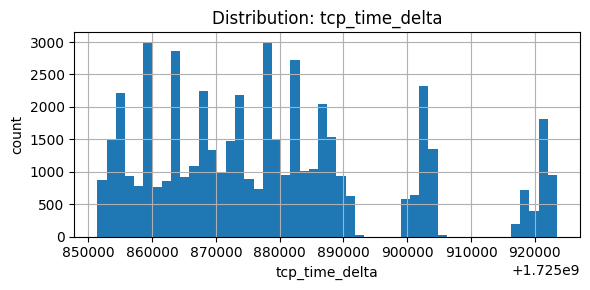

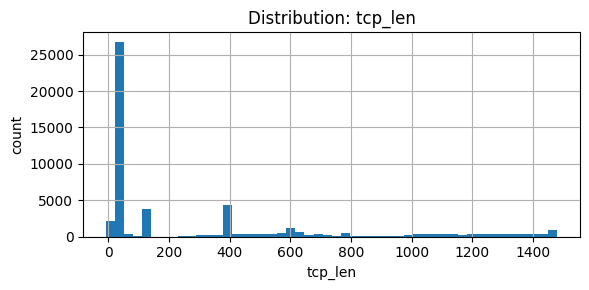

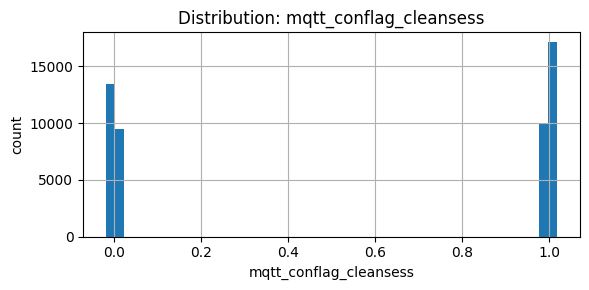

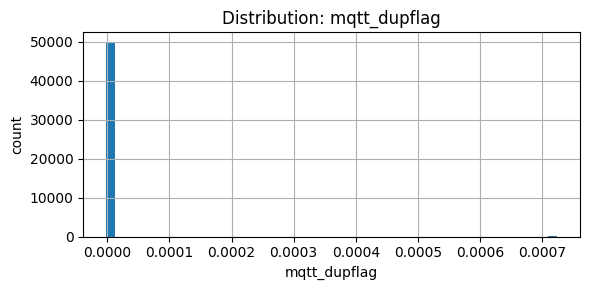

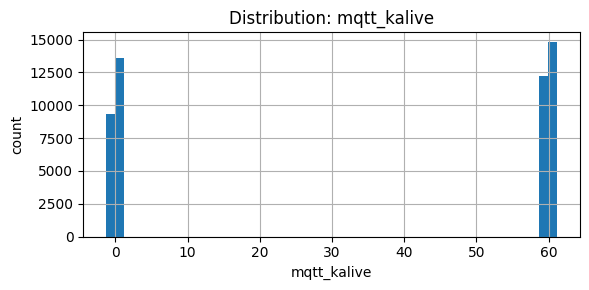

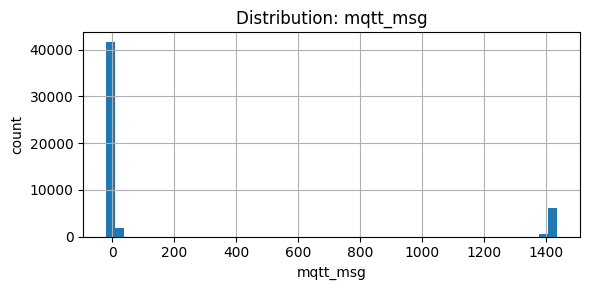

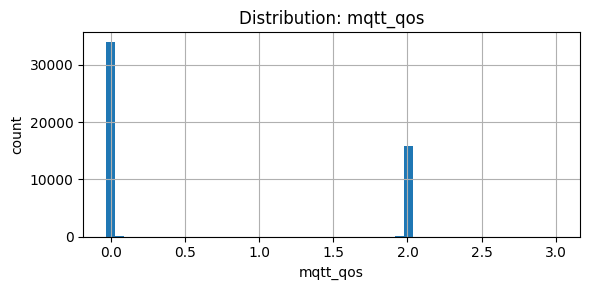

In [9]:
# 7. Plots: histograms for numeric columns (use a sample if dataset is large)
import matplotlib.pyplot as plt

# choose sample size (toPandas can OOM if huge); sample fraction or limit
SAMPLE_ROWS = 50000   # reduce if memory issues
total = df.count()
frac = min(1.0, SAMPLE_ROWS / total)

pdf = df.sample(withReplacement=False, fraction=frac, seed=42).toPandas()

# Histograms for numeric columns (one figure per column)
for c in numeric_cols:
    plt.figure(figsize=(6,3))
    pdf[c].hist(bins=50)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


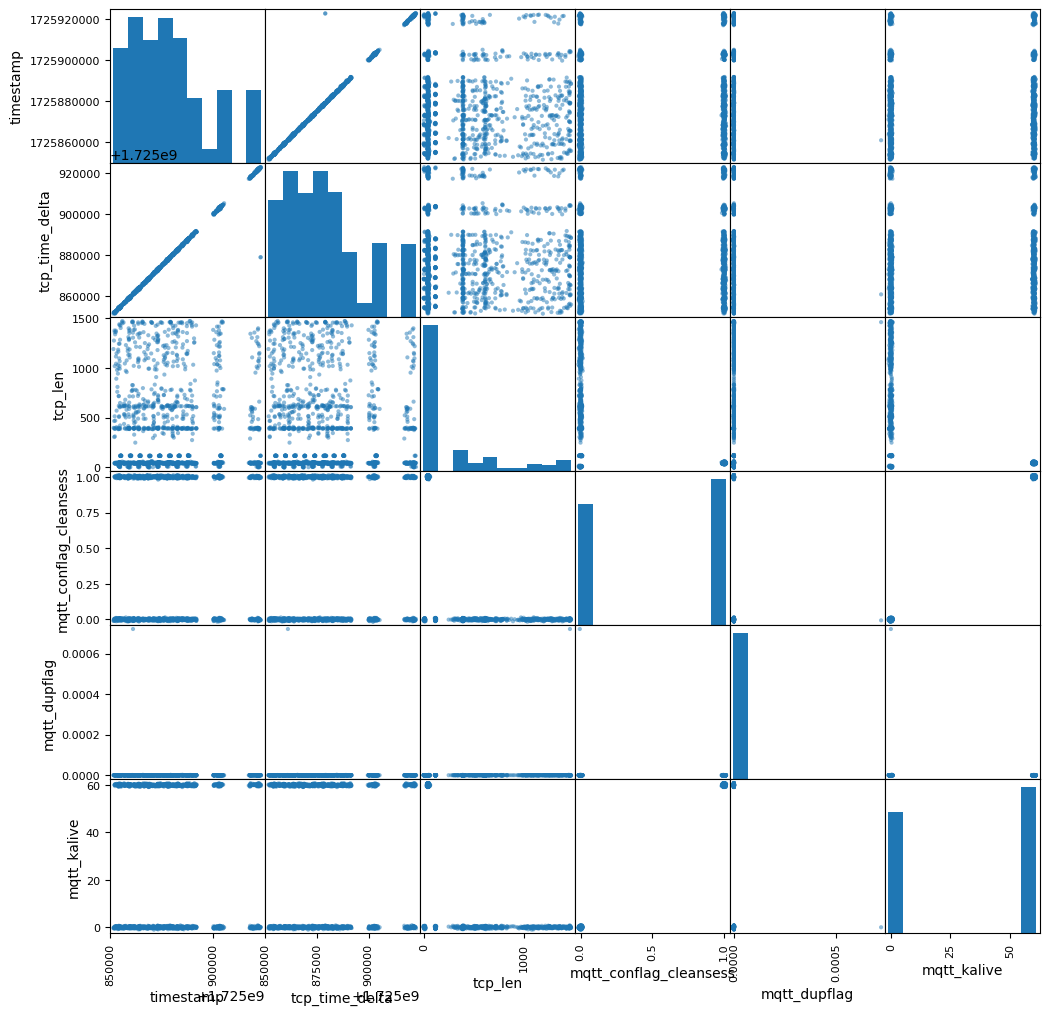

In [10]:
# 8. Pairwise scatter matrix for a few numeric columns (choose up to ~6 to avoid huge plots)
from pandas.plotting import scatter_matrix

pair_cols = numeric_cols[:6]   # limit to first 6 numeric columns
if len(pair_cols) >= 2:
    small_pdf = pdf[pair_cols].sample(n=min(2000, len(pdf)), random_state=42)
    scatter_matrix(small_pdf, figsize=(12,12), diagonal='hist')
else:
    print("Not enough numeric columns for pairwise scatter.")


In [11]:
# 9. Save basic outputs for report
# summary.toPandas() already exists; save correlation table and class counts if present
corr_df.to_csv("/kaggle/working/eda_correlation.csv", index=True) if 'corr_df' in globals() else None
if label_col:
    df.groupBy(label_col).count().toPandas().to_csv("/kaggle/working/class_balance.csv", index=False)
print("Saved EDA artifacts to /kaggle/working/")


Saved EDA artifacts to /kaggle/working/


In [12]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType

spark = SparkSession.builder.appName("Feature_Engineering").getOrCreate()

df = spark.read.option("header", True).option("inferSchema", True).csv("/kaggle/working/MQTT_FINAL_DATA_augmented.csv")
print("Rows:", df.count())
print("Columns:", len(df.columns))


25/11/24 05:22:14 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Rows: 1113536
Columns: 13


In [13]:
# Identify numeric columns
numeric_cols = [c for c, t in df.dtypes if t in ("int", "double", "float", "bigint")]

# Identify non-numeric as categorical (except label)
categorical_cols = [c for c in df.columns if c not in numeric_cols and c != "label"]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)


Numeric: ['timestamp', 'tcp_time_delta', 'tcp_len', 'mqtt_conflag_cleansess', 'mqtt_dupflag', 'mqtt_kalive', 'mqtt_msg', 'mqtt_qos']
Categorical: ['tcp_flags', 'mqtt_conack_flags', 'mqtt_conflags', 'mqtt_hdrflags']


In [14]:
from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(inputCol="label", outputCol="label_idx")
df = label_indexer.fit(df).transform(df)

df.select("label", "label_idx").show(10)


+----------+---------+
|     label|label_idx|
+----------+---------+
| malformed|      0.0|
| malformed|      0.0|
|   slowite|      3.0|
|bruteforce|      2.0|
| malformed|      0.0|
|legitimate|      4.0|
|bruteforce|      2.0|
| malformed|      0.0|
|bruteforce|      2.0|
|bruteforce|      2.0|
+----------+---------+
only showing top 10 rows



In [15]:
from pyspark.ml.feature import StringIndexer

cat_indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]


In [16]:
from pyspark.ml.feature import VectorAssembler

feature_inputs = numeric_cols + [c + "_idx" for c in categorical_cols]

assembler = VectorAssembler(inputCols=feature_inputs, outputCol="features")


In [17]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features", outputCol="scaled_features")


In [18]:
from pyspark.ml import Pipeline

# if label_idx already exists, exclude label_indexer from pipeline stages
if "label_idx" in df.columns:
    print("label_idx already present — excluding label_indexer from pipeline.")
    stages = cat_indexers + [assembler, scaler]
else:
    stages = cat_indexers + [label_indexer, assembler, scaler]

pipeline = Pipeline(stages=stages)
model = pipeline.fit(df)
processed_df = model.transform(df)
processed_df.select("scaled_features", "label_idx").show(5)


label_idx already present — excluding label_indexer from pipeline.


+--------------------+---------+
|     scaled_features|label_idx|
+--------------------+---------+
|[92307.3305224612...|      0.0|
|[92306.5788776226...|      0.0|
|[92308.0324588123...|      3.0|
|[92307.8976282300...|      2.0|
|[92306.5826987413...|      0.0|
+--------------------+---------+
only showing top 5 rows



In [19]:
# Use this cell first. It will reuse processed_df if in memory, otherwise try parquet, else read CSV and expect scaled_features exists.
from pyspark.sql import SparkSession, functions as F
spark = SparkSession.builder.getOrCreate()

# prefer processed_df if present
try:
    processed_df
    print("Using existing processed_df in session.")
except NameError:
    import os
    if os.path.exists("/kaggle/working/MQTT_processed.parquet"):
        processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")
        print("Loaded processed parquet.")
    else:
        # Try reading full CSV and assume you have scaled_features column (rare); otherwise you must re-run FE pipeline.
        processed_df = spark.read.option("header", True).option("inferSchema", True).csv("/kaggle/working/MQTT_FINAL_DATA_augmented.csv")
        print("Loaded CSV — ensure you have 'scaled_features' column. If not, run Feature Engineering cell first.")
        
print("Columns:", processed_df.columns)
print("Count:", processed_df.count())


Using existing processed_df in session.
Columns: ['timestamp', 'tcp_flags', 'tcp_time_delta', 'tcp_len', 'mqtt_conack_flags', 'mqtt_conflag_cleansess', 'mqtt_conflags', 'mqtt_dupflag', 'mqtt_hdrflags', 'mqtt_kalive', 'mqtt_msg', 'mqtt_qos', 'label', 'label_idx', 'tcp_flags_idx', 'mqtt_conack_flags_idx', 'mqtt_conflags_idx', 'mqtt_hdrflags_idx', 'features', 'scaled_features']
Count: 1113536


In [20]:
# 80/20 split with fixed seed
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())


Train: 890563 Test: 222973


Train: 890563 Test: 222973


LR training done.


Logistic Regression metrics: {'accuracy': 0.5773299906266678, 'weighted_precision': 0.5425010667978744, 'weighted_recall': 0.5773299906266678, 'weighted_f1': 0.5218887616931502}


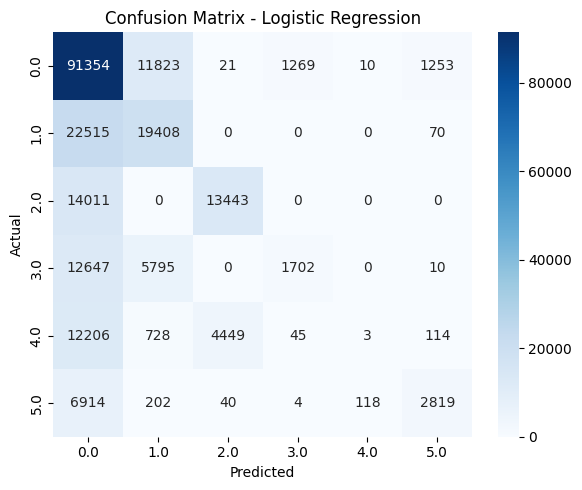

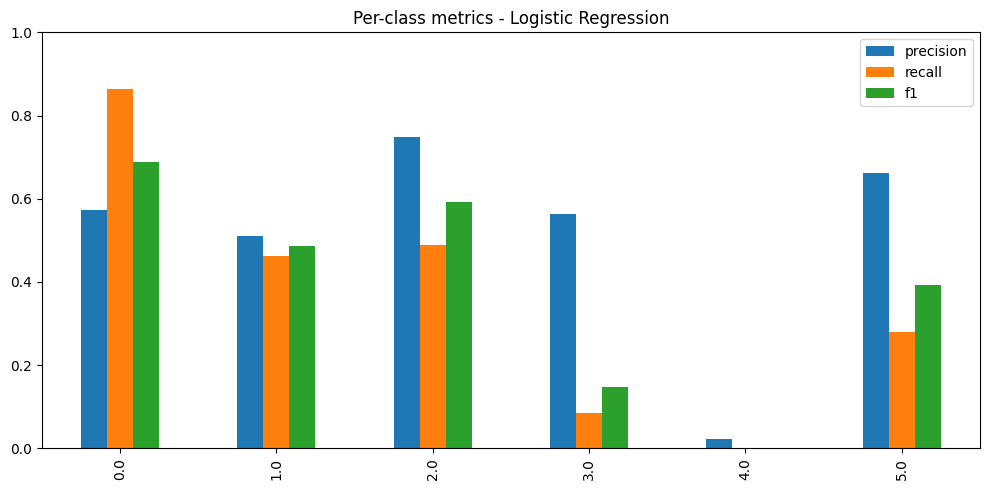

LR finished. Metrics and plots saved to /kaggle/working/


In [22]:
# A. Logistic Regression - full training + eval + plots
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# load processed_df (uses scaled_features & label_idx)
try:
    processed_df
except NameError:
    processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")

# Train/test split
train_df, test_df = processed_df.randomSplit([0.8,0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())

# Create and fit Logistic Regression
lr = LogisticRegression(featuresCol="scaled_features", labelCol="label_idx", maxIter=200, regParam=0.01, elasticNetParam=0.0)
lr_model = lr.fit(train_df)
print("LR training done.")

# Predict
pred_lr = lr_model.transform(test_df).select("label_idx","prediction","probability","rawPrediction")
pred_lr.cache()

# Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

metrics = {
    "accuracy": eval_acc.evaluate(pred_lr),
    "weighted_precision": eval_prec.evaluate(pred_lr),
    "weighted_recall": eval_rec.evaluate(pred_lr),
    "weighted_f1": eval_f1.evaluate(pred_lr)
}
print("Logistic Regression metrics:", metrics)

# Save metrics
pd.DataFrame([metrics], index=["LogisticRegression"]).to_csv("/kaggle/working/metrics_lr.csv")

# Confusion matrix
cm_pd = pred_lr.groupBy("label_idx","prediction").count().toPandas()
cm_pivot = cm_pd.pivot(index="label_idx", columns="prediction", values="count").fillna(0).astype(int)
labels = sorted(list(set(cm_pivot.index.tolist() + cm_pivot.columns.tolist())))
cm_final = pd.DataFrame(0, index=labels, columns=labels)
for i in cm_pivot.index:
    for j in cm_pivot.columns:
        cm_final.at[i,j] = cm_pivot.at[i,j]

cm_final.to_csv("/kaggle/working/confusion_lr.csv")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_lr.png")
plt.show()

# Per-class metrics derived from CM
labels = list(cm_final.index)
per_class = {}
for k,lab in enumerate(labels):
    tp = cm_final.iat[k,k]
    fp = cm_final.iloc[:,k].sum() - tp
    fn = cm_final.iloc[k,:].sum() - tp
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
    per_class[lab] = {"precision":prec, "recall":rec, "f1":f1, "support": int(cm_final.iloc[k,:].sum())}

per_df = pd.DataFrame(per_class).T
per_df.to_csv("/kaggle/working/per_class_lr.csv")
per_df[["precision","recall","f1"]].plot(kind="bar", figsize=(10,5))
plt.ylim(0,1)
plt.title("Per-class metrics - Logistic Regression")
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_lr.png")
plt.show()

# Save model
lr_model.write().overwrite().save("/kaggle/working/lr_model")

print("LR finished. Metrics and plots saved to /kaggle/working/")


Train: 890563 Test: 222973


Decision Tree training done.


Decision Tree metrics: {'accuracy': 0.8701277733178456, 'weighted_precision': 0.8753871100604385, 'weighted_recall': 0.8701277733178456, 'weighted_f1': 0.8523474260497821}


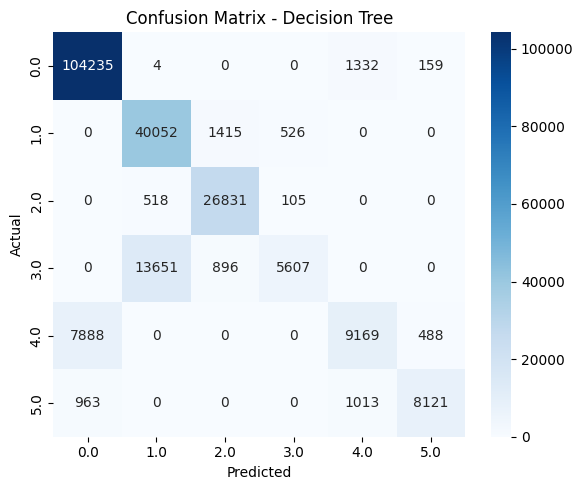

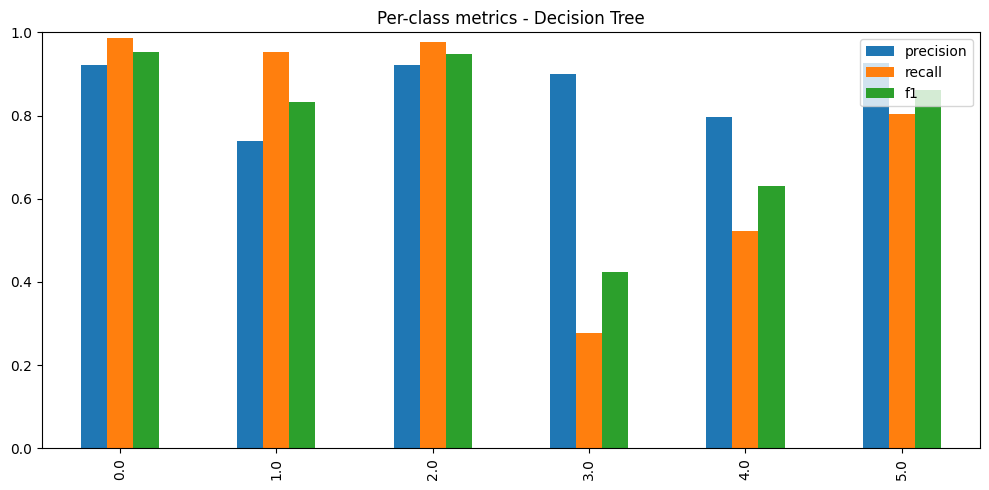

Decision Tree finished. Metrics and plots saved to /kaggle/working/


In [23]:
# B. Decision Tree Classifier - full training + eval + plots

from pyspark.sql import SparkSession
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# Load processed_df
try:
    processed_df
except NameError:
    processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")

# Train/test split
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())

# Create and fit Decision Tree
dt = DecisionTreeClassifier(
    featuresCol="scaled_features",
    labelCol="label_idx",
    maxDepth=10,
    minInstancesPerNode=5
)

dt_model = dt.fit(train_df)
print("Decision Tree training done.")

# Predict
pred_dt = dt_model.transform(test_df).select("label_idx", "prediction", "probability")
pred_dt.cache()

# Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

metrics = {
    "accuracy": eval_acc.evaluate(pred_dt),
    "weighted_precision": eval_prec.evaluate(pred_dt),
    "weighted_recall": eval_rec.evaluate(pred_dt),
    "weighted_f1": eval_f1.evaluate(pred_dt)
}
print("Decision Tree metrics:", metrics)

# Save metrics
pd.DataFrame([metrics], index=["DecisionTree"]).to_csv("/kaggle/working/metrics_dt.csv")

# Confusion matrix
cm_pd = pred_dt.groupBy("label_idx", "prediction").count().toPandas()
cm_pivot = cm_pd.pivot(index="label_idx", columns="prediction", values="count").fillna(0).astype(int)

labels = sorted(list(set(cm_pivot.index.tolist() + cm_pivot.columns.tolist())))
cm_final = pd.DataFrame(0, index=labels, columns=labels)

for i in cm_pivot.index:
    for j in cm_pivot.columns:
        cm_final.at[i, j] = cm_pivot.at[i, j]

cm_final.to_csv("/kaggle/working/confusion_dt.csv")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_dt.png")
plt.show()

# Per-class metrics
labels = list(cm_final.index)
per_class = {}

for k, lab in enumerate(labels):
    tp = cm_final.iat[k, k]
    fp = cm_final.iloc[:, k].sum() - tp
    fn = cm_final.iloc[k, :].sum() - tp
    
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    
    per_class[lab] = {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": int(cm_final.iloc[k, :].sum())
    }

per_df = pd.DataFrame(per_class).T
per_df.to_csv("/kaggle/working/per_class_dt.csv")

# Plot per-class metrics
per_df[["precision", "recall", "f1"]].plot(kind="bar", figsize=(10,5))
plt.ylim(0,1)
plt.title("Per-class metrics - Decision Tree")
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_dt.png")
plt.show()

# Save model
dt_model.write().overwrite().save("/kaggle/working/dt_model")

print("Decision Tree finished. Metrics and plots saved to /kaggle/working/")


Decision tree with max depth 12


Train: 890563 Test: 222973


Decision Tree training done.


Decision Tree metrics: {'accuracy': 0.8755095908473223, 'weighted_precision': 0.8734813265658595, 'weighted_recall': 0.8755095908473223, 'weighted_f1': 0.8627765869013675}


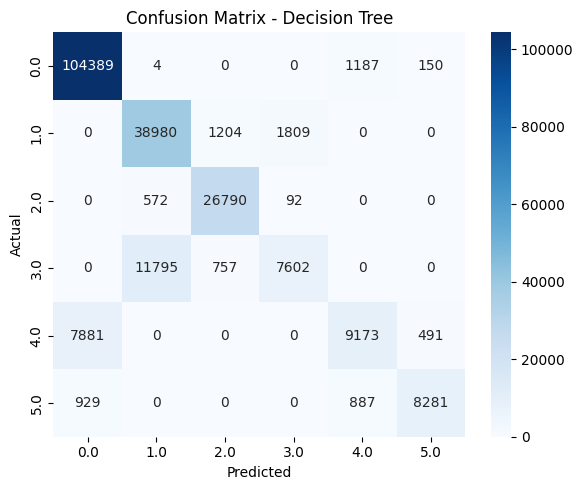

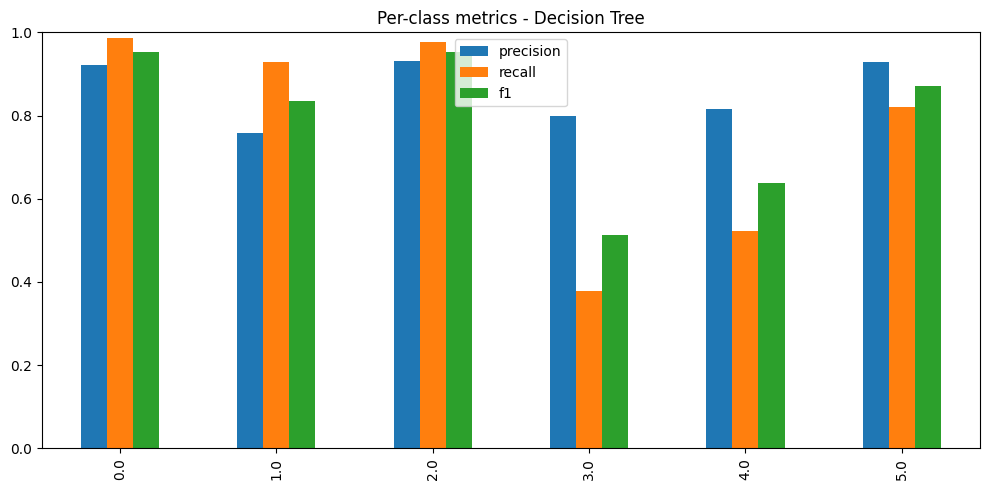

Decision Tree finished. Metrics and plots saved to /kaggle/working/


In [24]:
# B. Decision Tree Classifier - full training + eval + plots

from pyspark.sql import SparkSession
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# Load processed_df
try:
    processed_df
except NameError:
    processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")

# Train/test split
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())

# Create and fit Decision Tree
dt = DecisionTreeClassifier(
    featuresCol="scaled_features",
    labelCol="label_idx",
    maxDepth=12,
    minInstancesPerNode=5
)

dt_model = dt.fit(train_df)
print("Decision Tree training done.")

# Predict
pred_dt = dt_model.transform(test_df).select("label_idx", "prediction", "probability")
pred_dt.cache()

# Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

metrics = {
    "accuracy": eval_acc.evaluate(pred_dt),
    "weighted_precision": eval_prec.evaluate(pred_dt),
    "weighted_recall": eval_rec.evaluate(pred_dt),
    "weighted_f1": eval_f1.evaluate(pred_dt)
}
print("Decision Tree metrics:", metrics)

# Save metrics
pd.DataFrame([metrics], index=["DecisionTree"]).to_csv("/kaggle/working/metrics_dt.csv")

# Confusion matrix
cm_pd = pred_dt.groupBy("label_idx", "prediction").count().toPandas()
cm_pivot = cm_pd.pivot(index="label_idx", columns="prediction", values="count").fillna(0).astype(int)

labels = sorted(list(set(cm_pivot.index.tolist() + cm_pivot.columns.tolist())))
cm_final = pd.DataFrame(0, index=labels, columns=labels)

for i in cm_pivot.index:
    for j in cm_pivot.columns:
        cm_final.at[i, j] = cm_pivot.at[i, j]

cm_final.to_csv("/kaggle/working/confusion_dt.csv")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_dt.png")
plt.show()

# Per-class metrics
labels = list(cm_final.index)
per_class = {}

for k, lab in enumerate(labels):
    tp = cm_final.iat[k, k]
    fp = cm_final.iloc[:, k].sum() - tp
    fn = cm_final.iloc[k, :].sum() - tp
    
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    
    per_class[lab] = {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": int(cm_final.iloc[k, :].sum())
    }

per_df = pd.DataFrame(per_class).T
per_df.to_csv("/kaggle/working/per_class_dt.csv")

# Plot per-class metrics
per_df[["precision", "recall", "f1"]].plot(kind="bar", figsize=(10,5))
plt.ylim(0,1)
plt.title("Per-class metrics - Decision Tree")
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_dt.png")
plt.show()

# Save model
dt_model.write().overwrite().save("/kaggle/working/dt_model")

print("Decision Tree finished. Metrics and plots saved to /kaggle/working/")


**WITH DEPTH 14 **

Train: 890563 Test: 222973


Decision Tree training done.


Decision Tree metrics: {'accuracy': 0.8826763778574087, 'weighted_precision': 0.8799756092700038, 'weighted_recall': 0.8826763778574087, 'weighted_f1': 0.8722224784988306}


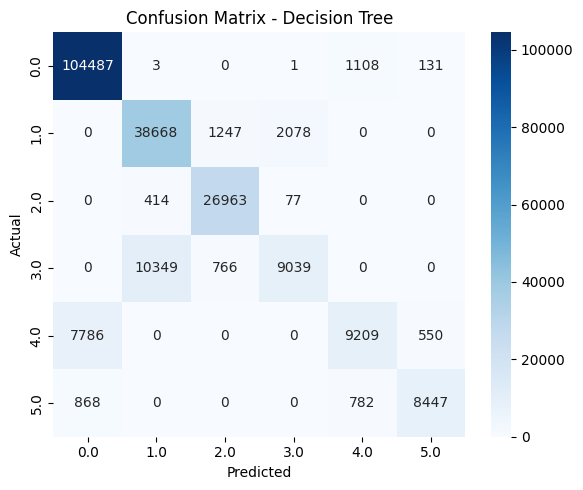

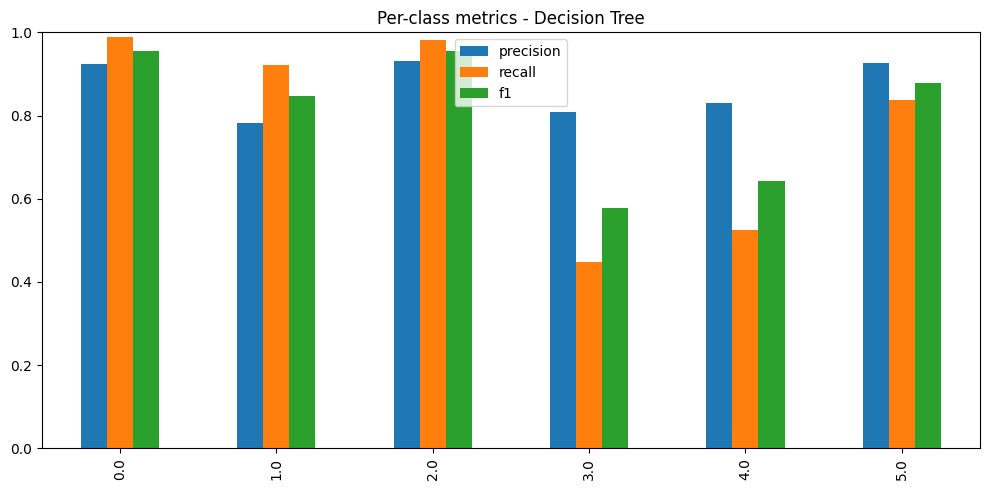

Decision Tree finished. Metrics and plots saved to /kaggle/working/


In [25]:
# B. Decision Tree Classifier - full training + eval + plots

from pyspark.sql import SparkSession
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# Load processed_df
try:
    processed_df
except NameError:
    processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")

# Train/test split
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())

# Create and fit Decision Tree
dt = DecisionTreeClassifier(
    featuresCol="scaled_features",
    labelCol="label_idx",
    maxDepth=14,
    minInstancesPerNode=5
)

dt_model = dt.fit(train_df)
print("Decision Tree training done.")

# Predict
pred_dt = dt_model.transform(test_df).select("label_idx", "prediction", "probability")
pred_dt.cache()

# Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

metrics = {
    "accuracy": eval_acc.evaluate(pred_dt),
    "weighted_precision": eval_prec.evaluate(pred_dt),
    "weighted_recall": eval_rec.evaluate(pred_dt),
    "weighted_f1": eval_f1.evaluate(pred_dt)
}
print("Decision Tree metrics:", metrics)

# Save metrics
pd.DataFrame([metrics], index=["DecisionTree"]).to_csv("/kaggle/working/metrics_dt.csv")

# Confusion matrix
cm_pd = pred_dt.groupBy("label_idx", "prediction").count().toPandas()
cm_pivot = cm_pd.pivot(index="label_idx", columns="prediction", values="count").fillna(0).astype(int)

labels = sorted(list(set(cm_pivot.index.tolist() + cm_pivot.columns.tolist())))
cm_final = pd.DataFrame(0, index=labels, columns=labels)

for i in cm_pivot.index:
    for j in cm_pivot.columns:
        cm_final.at[i, j] = cm_pivot.at[i, j]

cm_final.to_csv("/kaggle/working/confusion_dt.csv")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_dt.png")
plt.show()

# Per-class metrics
labels = list(cm_final.index)
per_class = {}

for k, lab in enumerate(labels):
    tp = cm_final.iat[k, k]
    fp = cm_final.iloc[:, k].sum() - tp
    fn = cm_final.iloc[k, :].sum() - tp
    
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    
    per_class[lab] = {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": int(cm_final.iloc[k, :].sum())
    }

per_df = pd.DataFrame(per_class).T
per_df.to_csv("/kaggle/working/per_class_dt.csv")

# Plot per-class metrics
per_df[["precision", "recall", "f1"]].plot(kind="bar", figsize=(10,5))
plt.ylim(0,1)
plt.title("Per-class metrics - Decision Tree")
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_dt.png")
plt.show()

# Save model
dt_model.write().overwrite().save("/kaggle/working/dt_model")

print("Decision Tree finished. Metrics and plots saved to /kaggle/working/")


Train: 890563 Test: 222973


Decision Tree training done.


Decision Tree metrics: {'accuracy': 0.882156135496226, 'weighted_precision': 0.8794473728835548, 'weighted_recall': 0.882156135496226, 'weighted_f1': 0.8716292091356326}


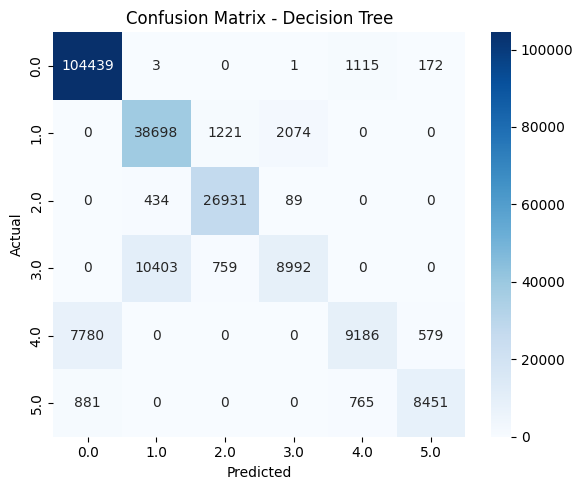

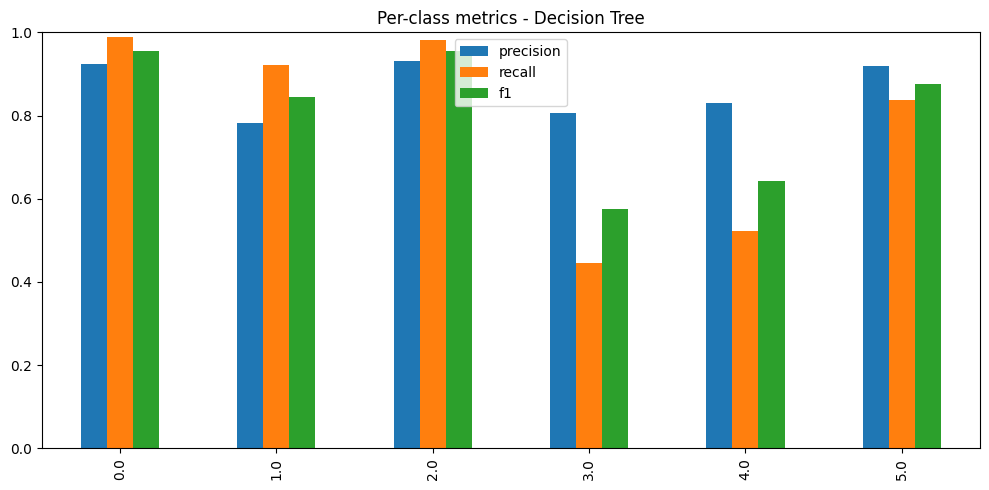

Decision Tree finished. Metrics and plots saved to /kaggle/working/


In [26]:
# B. Decision Tree Classifier - full training + eval + plots

from pyspark.sql import SparkSession
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# Load processed_df
try:
    processed_df
except NameError:
    processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")

# Train/test split
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())

# Create and fit Decision Tree
dt = DecisionTreeClassifier(
    featuresCol="scaled_features",
    labelCol="label_idx",
    maxDepth=14,
    minInstancesPerNode=20
)

dt_model = dt.fit(train_df)
print("Decision Tree training done.")

# Predict
pred_dt = dt_model.transform(test_df).select("label_idx", "prediction", "probability")
pred_dt.cache()

# Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

metrics = {
    "accuracy": eval_acc.evaluate(pred_dt),
    "weighted_precision": eval_prec.evaluate(pred_dt),
    "weighted_recall": eval_rec.evaluate(pred_dt),
    "weighted_f1": eval_f1.evaluate(pred_dt)
}
print("Decision Tree metrics:", metrics)

# Save metrics
pd.DataFrame([metrics], index=["DecisionTree"]).to_csv("/kaggle/working/metrics_dt.csv")

# Confusion matrix
cm_pd = pred_dt.groupBy("label_idx", "prediction").count().toPandas()
cm_pivot = cm_pd.pivot(index="label_idx", columns="prediction", values="count").fillna(0).astype(int)

labels = sorted(list(set(cm_pivot.index.tolist() + cm_pivot.columns.tolist())))
cm_final = pd.DataFrame(0, index=labels, columns=labels)

for i in cm_pivot.index:
    for j in cm_pivot.columns:
        cm_final.at[i, j] = cm_pivot.at[i, j]

cm_final.to_csv("/kaggle/working/confusion_dt.csv")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_dt.png")
plt.show()

# Per-class metrics
labels = list(cm_final.index)
per_class = {}

for k, lab in enumerate(labels):
    tp = cm_final.iat[k, k]
    fp = cm_final.iloc[:, k].sum() - tp
    fn = cm_final.iloc[k, :].sum() - tp
    
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    
    per_class[lab] = {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": int(cm_final.iloc[k, :].sum())
    }

per_df = pd.DataFrame(per_class).T
per_df.to_csv("/kaggle/working/per_class_dt.csv")

# Plot per-class metrics
per_df[["precision", "recall", "f1"]].plot(kind="bar", figsize=(10,5))
plt.ylim(0,1)
plt.title("Per-class metrics - Decision Tree")
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_dt.png")
plt.show()

# Save model
dt_model.write().overwrite().save("/kaggle/working/dt_model")

print("Decision Tree finished. Metrics and plots saved to /kaggle/working/")


In [ ]:
NOW FOR ENTROPY 

Train: 890563 Test: 222973


Decision Tree training done.


Decision Tree metrics: {'accuracy': 0.882156135496226, 'weighted_precision': 0.8794473728835548, 'weighted_recall': 0.882156135496226, 'weighted_f1': 0.8716292091356326}


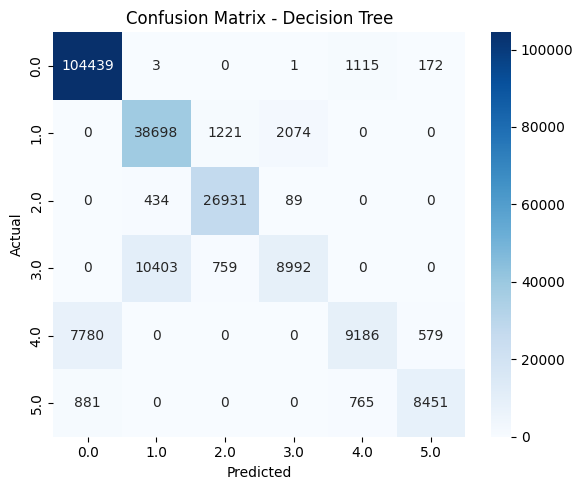

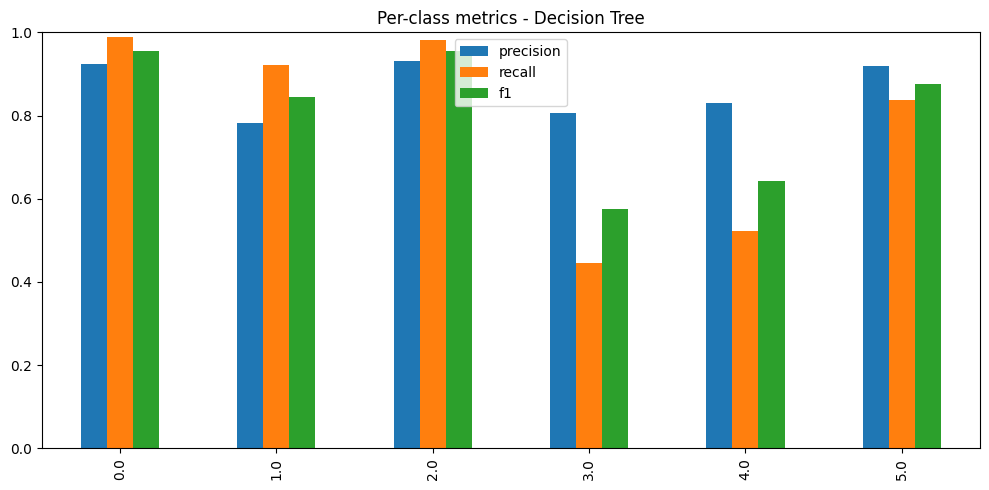

Decision Tree finished. Metrics and plots saved to /kaggle/working/


In [27]:
# B. Decision Tree Classifier - full training + eval + plots

from pyspark.sql import SparkSession
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# Load processed_df
try:
    processed_df
except NameError:
    processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")

# Train/test split
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())

# Create and fit Decision Tree
dt = DecisionTreeClassifier(
    featuresCol="scaled_features",
    labelCol="label_idx",
    maxDepth=14,
    minInstancesPerNode=20,
    impurity="gini"
)

dt_model = dt.fit(train_df)
print("Decision Tree training done.")

# Predict
pred_dt = dt_model.transform(test_df).select("label_idx", "prediction", "probability")
pred_dt.cache()

# Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

metrics = {
    "accuracy": eval_acc.evaluate(pred_dt),
    "weighted_precision": eval_prec.evaluate(pred_dt),
    "weighted_recall": eval_rec.evaluate(pred_dt),
    "weighted_f1": eval_f1.evaluate(pred_dt)
}
print("Decision Tree metrics:", metrics)

# Save metrics
pd.DataFrame([metrics], index=["DecisionTree"]).to_csv("/kaggle/working/metrics_dt.csv")

# Confusion matrix
cm_pd = pred_dt.groupBy("label_idx", "prediction").count().toPandas()
cm_pivot = cm_pd.pivot(index="label_idx", columns="prediction", values="count").fillna(0).astype(int)

labels = sorted(list(set(cm_pivot.index.tolist() + cm_pivot.columns.tolist())))
cm_final = pd.DataFrame(0, index=labels, columns=labels)

for i in cm_pivot.index:
    for j in cm_pivot.columns:
        cm_final.at[i, j] = cm_pivot.at[i, j]

cm_final.to_csv("/kaggle/working/confusion_dt.csv")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_dt.png")
plt.show()

# Per-class metrics
labels = list(cm_final.index)
per_class = {}

for k, lab in enumerate(labels):
    tp = cm_final.iat[k, k]
    fp = cm_final.iloc[:, k].sum() - tp
    fn = cm_final.iloc[k, :].sum() - tp
    
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    
    per_class[lab] = {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": int(cm_final.iloc[k, :].sum())
    }

per_df = pd.DataFrame(per_class).T
per_df.to_csv("/kaggle/working/per_class_dt.csv")

# Plot per-class metrics
per_df[["precision", "recall", "f1"]].plot(kind="bar", figsize=(10,5))
plt.ylim(0,1)
plt.title("Per-class metrics - Decision Tree")
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_dt.png")
plt.show()

# Save model
dt_model.write().overwrite().save("/kaggle/working/dt_model")

print("Decision Tree finished. Metrics and plots saved to /kaggle/working/")


Train: 890563 Test: 222973


Decision Tree training done.


Decision Tree metrics: {'accuracy': 0.884062195871249, 'weighted_precision': 0.8817711785807446, 'weighted_recall': 0.884062195871249, 'weighted_f1': 0.8744600141230477}


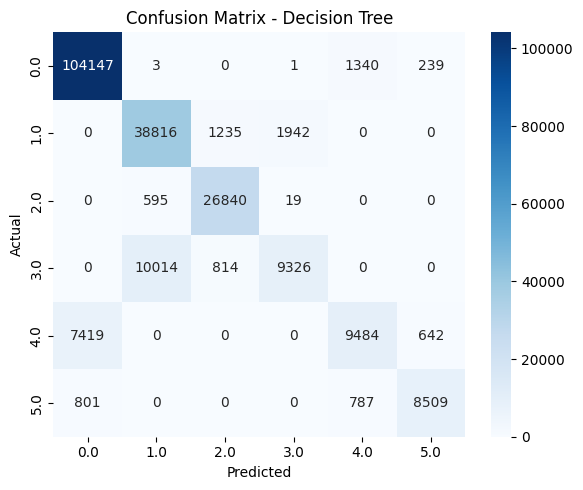

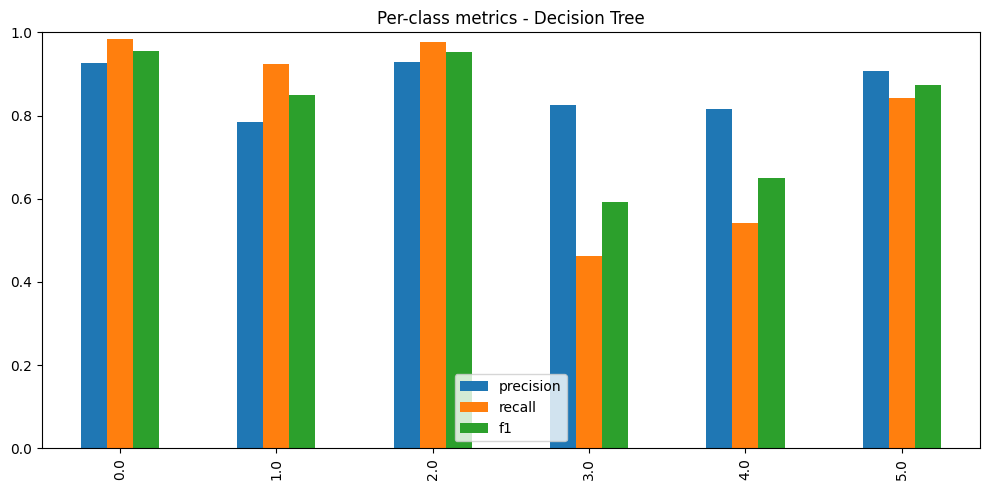

Decision Tree finished. Metrics and plots saved to /kaggle/working/


In [28]:
# B. Decision Tree Classifier - full training + eval + plots

from pyspark.sql import SparkSession
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# Load processed_df
try:
    processed_df
except NameError:
    processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")

# Train/test split
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())

# Create and fit Decision Tree
dt = DecisionTreeClassifier(
    featuresCol="scaled_features",
    labelCol="label_idx",
    maxDepth=14,
    minInstancesPerNode=20,
    impurity="entropy"
)

dt_model = dt.fit(train_df)
print("Decision Tree training done.")

# Predict
pred_dt = dt_model.transform(test_df).select("label_idx", "prediction", "probability")
pred_dt.cache()

# Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

metrics = {
    "accuracy": eval_acc.evaluate(pred_dt),
    "weighted_precision": eval_prec.evaluate(pred_dt),
    "weighted_recall": eval_rec.evaluate(pred_dt),
    "weighted_f1": eval_f1.evaluate(pred_dt)
}
print("Decision Tree metrics:", metrics)

# Save metrics
pd.DataFrame([metrics], index=["DecisionTree"]).to_csv("/kaggle/working/metrics_dt.csv")

# Confusion matrix
cm_pd = pred_dt.groupBy("label_idx", "prediction").count().toPandas()
cm_pivot = cm_pd.pivot(index="label_idx", columns="prediction", values="count").fillna(0).astype(int)

labels = sorted(list(set(cm_pivot.index.tolist() + cm_pivot.columns.tolist())))
cm_final = pd.DataFrame(0, index=labels, columns=labels)

for i in cm_pivot.index:
    for j in cm_pivot.columns:
        cm_final.at[i, j] = cm_pivot.at[i, j]

cm_final.to_csv("/kaggle/working/confusion_dt.csv")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_dt.png")
plt.show()

# Per-class metrics
labels = list(cm_final.index)
per_class = {}

for k, lab in enumerate(labels):
    tp = cm_final.iat[k, k]
    fp = cm_final.iloc[:, k].sum() - tp
    fn = cm_final.iloc[k, :].sum() - tp
    
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    
    per_class[lab] = {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": int(cm_final.iloc[k, :].sum())
    }

per_df = pd.DataFrame(per_class).T
per_df.to_csv("/kaggle/working/per_class_dt.csv")

# Plot per-class metrics
per_df[["precision", "recall", "f1"]].plot(kind="bar", figsize=(10,5))
plt.ylim(0,1)
plt.title("Per-class metrics - Decision Tree")
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_dt.png")
plt.show()

# Save model
dt_model.write().overwrite().save("/kaggle/working/dt_model")

print("Decision Tree finished. Metrics and plots saved to /kaggle/working/")


In [ ]:
*******Random forest **********

Train: 890563 Test: 222973


25/11/24 05:42:26 WARN DAGScheduler: Broadcasting large task binary with size 1217.1 KiB
25/11/24 05:42:54 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/11/24 05:43:29 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/11/24 05:44:08 WARN DAGScheduler: Broadcasting large task binary with size 6.6 MiB
25/11/24 05:44:53 WARN DAGScheduler: Broadcasting large task binary with size 1605.9 KiB
25/11/24 05:44:55 WARN DAGScheduler: Broadcasting large task binary with size 11.0 MiB
25/11/24 05:45:49 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
25/11/24 05:45:52 WARN DAGScheduler: Broadcasting large task binary with size 17.6 MiB
25/11/24 05:46:53 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/11/24 05:46:58 WARN DAGScheduler: Broadcasting large task binary with size 22.3 MiB
25/11/24 05:47:50 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB
25/11/24 05:47:55 WARN DAGScheduler: Broadcas

Random Forest training done.


25/11/24 05:49:22 WARN DAGScheduler: Broadcasting large task binary with size 20.9 MiB
25/11/24 05:49:36 WARN DAGScheduler: Broadcasting large task binary with size 20.9 MiB
25/11/24 05:49:37 WARN DAGScheduler: Broadcasting large task binary with size 20.9 MiB
25/11/24 05:49:39 WARN DAGScheduler: Broadcasting large task binary with size 20.9 MiB
25/11/24 05:49:40 WARN DAGScheduler: Broadcasting large task binary with size 20.9 MiB


Random Forest metrics: {'accuracy': 0.8794383176438403, 'weighted_precision': 0.8841482945594985, 'weighted_recall': 0.8794383176438403, 'weighted_f1': 0.8639358097801239}


25/11/24 05:49:42 WARN DAGScheduler: Broadcasting large task binary with size 20.9 MiB
25/11/24 05:49:44 WARN DAGScheduler: Broadcasting large task binary with size 20.9 MiB


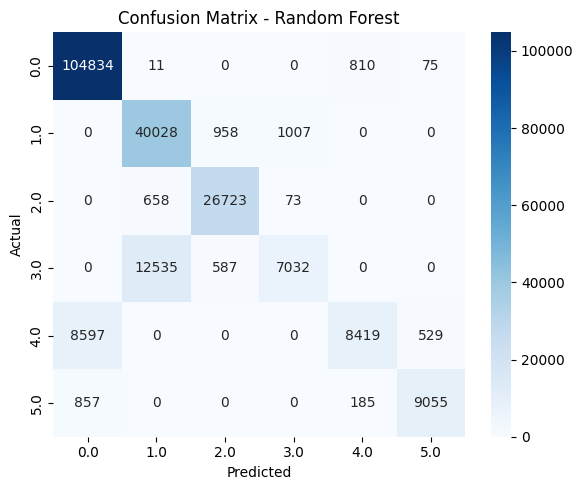

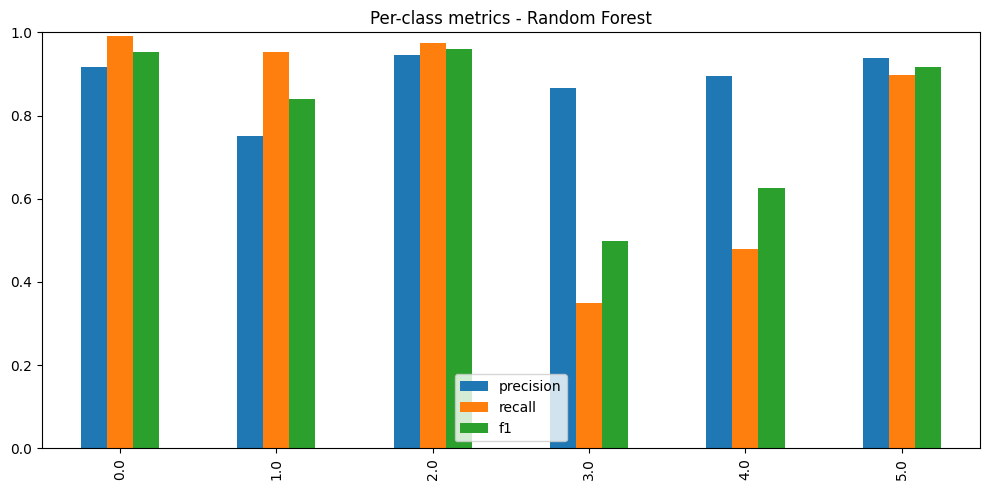

25/11/24 05:49:45 WARN TaskSetManager: Stage 496 contains a task of very large size (5537 KiB). The maximum recommended task size is 1000 KiB.


Random Forest finished. Metrics and plots saved to /kaggle/working/


In [29]:
# B. Random Forest Classifier - full training + eval + plots

from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# Load processed_df
try:
    processed_df
except NameError:
    processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")

# Train/test split
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())

# -----------------------------
# 🔵 Random Forest Classifier
# -----------------------------
rf = RandomForestClassifier(
    featuresCol="scaled_features",
    labelCol="label_idx",

    # Hyperparameters you can tune later
    numTrees=200,               # number of trees
    maxDepth=12,                # tree depth
    maxBins=50,                 # discretization bins
    minInstancesPerNode=5,      # leaf size
    impurity="gini",            # gini / entropy
    featureSubsetStrategy="auto",  # sqrt/log2/all
    seed=42
)

rf_model = rf.fit(train_df)
print("Random Forest training done.")

# Predict
pred_rf = rf_model.transform(test_df).select("label_idx", "prediction", "probability")
pred_rf.cache()

# Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

metrics = {
    "accuracy": eval_acc.evaluate(pred_rf),
    "weighted_precision": eval_prec.evaluate(pred_rf),
    "weighted_recall": eval_rec.evaluate(pred_rf),
    "weighted_f1": eval_f1.evaluate(pred_rf)
}
print("Random Forest metrics:", metrics)

# Save metrics
pd.DataFrame([metrics], index=["RandomForest"]).to_csv("/kaggle/working/metrics_rf.csv")

# Confusion matrix
cm_pd = pred_rf.groupBy("label_idx", "prediction").count().toPandas()
cm_pivot = cm_pd.pivot(index="label_idx", columns="prediction", values="count").fillna(0).astype(int)

labels = sorted(list(set(cm_pivot.index.tolist() + cm_pivot.columns.tolist())))
cm_final = pd.DataFrame(0, index=labels, columns=labels)

for i in cm_pivot.index:
    for j in cm_pivot.columns:
        cm_final.at[i, j] = cm_pivot.at[i, j]

cm_final.to_csv("/kaggle/working/confusion_rf.csv")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_rf.png")
plt.show()

# Per-class metrics
labels = list(cm_final.index)
per_class = {}

for k, lab in enumerate(labels):
    tp = cm_final.iat[k, k]
    fp = cm_final.iloc[:, k].sum() - tp
    fn = cm_final.iloc[k, :].sum() - tp
    
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    
    per_class[lab] = {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": int(cm_final.iloc[k, :].sum())
    }

per_df = pd.DataFrame(per_class).T
per_df.to_csv("/kaggle/working/per_class_rf.csv")

# Plot per-class metrics
per_df[["precision", "recall", "f1"]].plot(kind="bar", figsize=(10,5))
plt.ylim(0,1)
plt.title("Per-class metrics - Random Forest")
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_rf.png")
plt.show()

# Save model
rf_model.write().overwrite().save("/kaggle/working/rf_model")

print("Random Forest finished. Metrics and plots saved to /kaggle/working/")


In [32]:
***GBT CLASSIFIER***



SyntaxError: invalid syntax (1692518372.py, line 1)

25/11/24 05:59:27 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB


25/11/24 06:00:34 WARN DAGScheduler: Broadcasting large task binary with size 5.7 MiB
25/11/24 06:01:44 WARN DAGScheduler: Broadcasting large task binary with size 1490.1 KiB


Train: 890563 Test: 222973


25/11/24 06:01:49 WARN DAGScheduler: Broadcasting large task binary with size 9.9 MiB
25/11/24 06:03:09 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
25/11/24 06:03:14 WARN DAGScheduler: Broadcasting large task binary with size 16.3 MiB
25/11/24 06:04:40 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
25/11/24 06:04:46 WARN DAGScheduler: Broadcasting large task binary with size 21.3 MiB
25/11/24 06:06:07 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB
25/11/24 06:06:14 WARN DAGScheduler: Broadcasting large task binary with size 22.3 MiB
25/11/24 06:07:12 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB
25/11/24 06:07:19 WARN DAGScheduler: Broadcasting large task binary with size 23.1 MiB
25/11/24 06:07:59 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB
25/11/24 06:08:06 WARN DAGScheduler: Broadcasting large task binary with size 22.9 MiB
25/11/24 06:08:57 WARN DAGScheduler: Broadcasting

GBT training done.


25/11/24 06:22:34 WARN DAGScheduler: Broadcasting large task binary with size 7.7 MiB
25/11/24 06:23:00 WARN DAGScheduler: Broadcasting large task binary with size 7.7 MiB
25/11/24 06:23:00 WARN DAGScheduler: Broadcasting large task binary with size 7.7 MiB
25/11/24 06:23:01 WARN DAGScheduler: Broadcasting large task binary with size 7.7 MiB
25/11/24 06:23:01 WARN DAGScheduler: Broadcasting large task binary with size 7.7 MiB


GBT metrics: {'accuracy': 0.9170796464145883, 'weighted_precision': 0.9159554980626575, 'weighted_recall': 0.9170796464145884, 'weighted_f1': 0.9122830844929845}


25/11/24 06:23:02 WARN DAGScheduler: Broadcasting large task binary with size 7.7 MiB
25/11/24 06:23:03 WARN DAGScheduler: Broadcasting large task binary with size 7.7 MiB


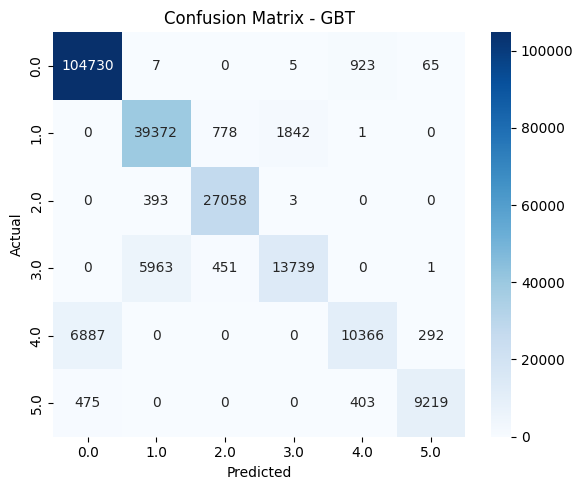

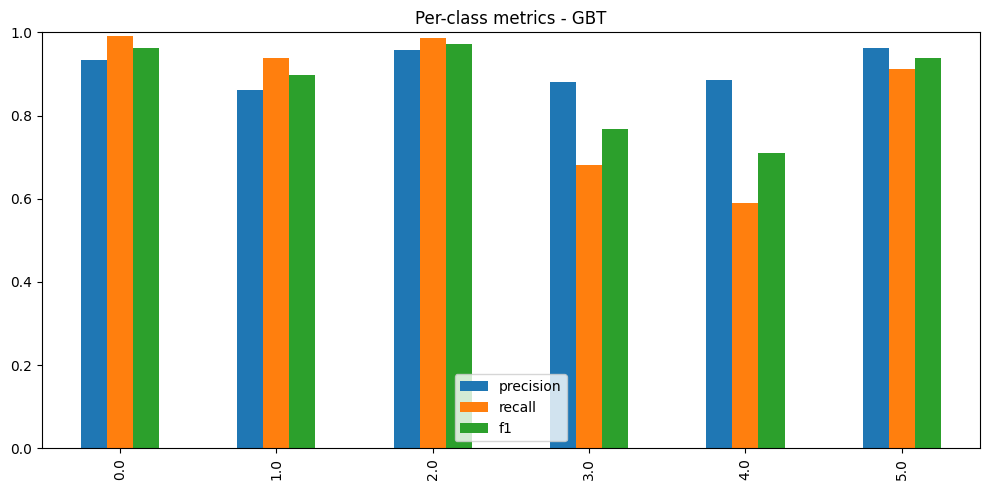

GBT finished. Metrics and plots saved to /kaggle/working/


In [33]:
# B. Gradient Boosted Tree Classifier - full training + eval + plots

from pyspark.sql import SparkSession
from pyspark.ml.classification import GBTClassifier, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# Load processed_df
try:
    processed_df
except NameError:
    processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")

# Train/test split
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())


# -----------------------------
# 🔵 Gradient Boosted Trees (GBT) + OneVsRest for multi-class
# -----------------------------
gbt = GBTClassifier(
    featuresCol="scaled_features",
    labelCol="label_idx",

    # Hyperparameters you can tune later
    maxDepth=8,
    maxBins=50,
    maxIter=50,          # number of boosting iterations
    stepSize=0.1,        # learning rate
    seed=42
)

# Wrap with One-vs-Rest for multi-class classification
ovr = OneVsRest(classifier=gbt,
                featuresCol="scaled_features",
                labelCol="label_idx")

gbt_model = ovr.fit(train_df)
print("GBT training done.")

# Predict
pred_gbt = gbt_model.transform(test_df).select("label_idx", "prediction")
pred_gbt.cache()

# Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

metrics = {
    "accuracy": eval_acc.evaluate(pred_gbt),
    "weighted_precision": eval_prec.evaluate(pred_gbt),
    "weighted_recall": eval_rec.evaluate(pred_gbt),
    "weighted_f1": eval_f1.evaluate(pred_gbt)
}
print("GBT metrics:", metrics)

# Save metrics
pd.DataFrame([metrics], index=["GBT"]).to_csv("/kaggle/working/metrics_gbt.csv")

# Confusion matrix
cm_pd = pred_gbt.groupBy("label_idx", "prediction").count().toPandas()
cm_pivot = cm_pd.pivot(index="label_idx", columns="prediction", values="count").fillna(0).astype(int)

labels = sorted(list(set(cm_pivot.index.tolist() + cm_pivot.columns.tolist())))
cm_final = pd.DataFrame(0, index=labels, columns=labels)

for i in cm_pivot.index:
    for j in cm_pivot.columns:
        cm_final.at[i, j] = cm_pivot.at[i, j]

cm_final.to_csv("/kaggle/working/confusion_gbt.csv")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - GBT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_gbt.png")
plt.show()

# Per-class metrics
labels = list(cm_final.index)
per_class = {}

for k, lab in enumerate(labels):
    tp = cm_final.iat[k, k]
    fp = cm_final.iloc[:, k].sum() - tp
    fn = cm_final.iloc[k, :].sum() - tp
    
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    
    per_class[lab] = {
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": int(cm_final.iloc[k, :].sum())
    }

per_df = pd.DataFrame(per_class).T
per_df.to_csv("/kaggle/working/per_class_gbt.csv")

# Plot per-class metrics
per_df[["precision", "recall", "f1"]].plot(kind="bar", figsize=(10,5))
plt.ylim(0,1)
plt.title("Per-class metrics - GBT")
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_gbt.png")
plt.show()

# Save model
gbt_model.write().overwrite().save("/kaggle/working/gbt_model")

print("GBT finished. Metrics and plots saved to /kaggle/working/")


In [35]:
# -----------------------------------------------------
# A. FIX NEGATIVE FEATURES FOR NAIVE BAYES
# -----------------------------------------------------

from pyspark.sql import SparkSession
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.feature import VectorAssembler, MinMaxScaler, SQLTransformer
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# Load processed_df
try:
    processed_df
except NameError:
    processed_df = spark.read.parquet("/kaggle/working/MQTT_processed.parquet")

# -----------------------------------------------------
# Step 1 — Convert scaled_features into a positive-only vector
# -----------------------------------------------------
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import array, col, lit

# Convert vector to array to find min element per row
df_arr = processed_df.withColumn("arr", vector_to_array("scaled_features"))

# Find global min (to ensure ALL features >= 1)
min_value = df_arr.selectExpr("array_min(arr) as minval").agg({"minval":"min"}).collect()[0][0]

shift_amount = abs(min_value) + 1.0   # ensures minimum value becomes 1

print("Global min:", min_value, " | Shift amount applied:", shift_amount)

from pyspark.sql.functions import expr

# Shift scaled_features => scaled_features_fixed
processed_fixed = df_arr.withColumn(
    "scaled_features_fixed",
    expr(f"transform(arr, x -> x + {shift_amount})")
)

# Convert back to vector
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["scaled_features_fixed"],
    outputCol="features_nb"
)
processed_fixed = assembler.transform(processed_fixed)

# Train/test split
train_df, test_df = processed_fixed.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())


# -----------------------------------------------------
# B. Train Naive Bayes
# -----------------------------------------------------

nb = NaiveBayes(
    featuresCol="features_nb",
    labelCol="label_idx",
    smoothing=1.0,
    modelType="multinomial"   # multinomial NB (for freq/count-like data)
)

nb_model = nb.fit(train_df)
print("Naive Bayes training done successfully.")


# -----------------------------------------------------
# C. Predict
# -----------------------------------------------------
pred_nb = nb_model.transform(test_df).select("label_idx", "prediction", "probability")
pred_nb.cache()

# -----------------------------------------------------
# D. Metrics
# -----------------------------------------------------
eval_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")

metrics = {
    "accuracy": eval_acc.evaluate(pred_nb),
    "weighted_precision": eval_prec.evaluate(pred_nb),
    "weighted_recall": eval_rec.evaluate(pred_nb),
    "weighted_f1": eval_f1.evaluate(pred_nb)
}
print("Naive Bayes metrics:", metrics)

pd.DataFrame([metrics], index=["NaiveBayes"]).to_csv("/kaggle/working/metrics_nb.csv")

# -----------------------------------------------------
# E. Confusion Matrix
# -----------------------------------------------------
cm_pd = pred_nb.groupBy("label_idx", "prediction").count().toPandas()
cm_pivot = cm_pd.pivot(index="label_idx", columns="prediction", values="count").fillna(0).astype(int)

labels = sorted(list(set(cm_pivot.index) | set(cm_pivot.columns)))
cm_final = pd.DataFrame(0, index=labels, columns=labels)

for r in cm_pivot.index:
    for c in cm_pivot.columns:
        cm_final.at[r, c] = cm_pivot.at[r, c]

cm_final.to_csv("/kaggle/working/confusion_nb.csv")

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_nb.png")
plt.show()

# -----------------------------------------------------
# F. Per-class metrics
# -----------------------------------------------------
labels = cm_final.index.tolist()
per_class = {}

for k, lab in enumerate(labels):
    tp = cm_final.iat[k, k]
    fp = cm_final.iloc[:, k].sum() - tp
    fn = cm_final.iloc[k, :].sum() - tp
    
    prec = tp/(tp+fp) if (tp+fp) else 0
    rec = tp/(tp+fn) if (tp+fn) else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    
    per_class[lab] = {"precision": prec, "recall": rec, "f1": f1}

per_df = pd.DataFrame(per_class).T
per_df.to_csv("/kaggle/working/per_class_nb.csv")

per_df.plot(kind="bar", figsize=(10,5))
plt.ylim(0,1)
plt.title("Per-class metrics - Naive Bayes")
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_nb.png")
plt.show()

# -----------------------------------------------------
# G. Save Model
# -----------------------------------------------------
nb_model.write().overwrite().save("/kaggle/working/nb_model")
print("Naive Bayes finished. Files saved to /kaggle/working/")


Global min: -0.2048574081801895  | Shift amount applied: 1.2048574081801895


IllegalArgumentException: Data type array<double> of column scaled_features_fixed is not supported.